# 阶段一：五子棋环境

## 目标
用五子棋快速建立 RL 核心概念的直觉：

| RL 概念 | 在本 notebook 的对应 |
|---|---|
| State | 棋盘局面（15×15 numpy array） |
| Action | 落子位置（0~224 的整数） |
| Reward | 赢 +1 / 输 -1 / 未结束 0 |
| Episode | 一局棋（有人赢或棋盘满） |

本 notebook 只做**环境建模**，不涉及训练。目标是跑通一局人机对战，验证环境逻辑正确。

## Cell 1：导入依赖

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Optional, Tuple

print("依赖导入成功")

Matplotlib is building the font cache; this may take a moment.


依赖导入成功


## Cell 2：GomokuEnv 核心类

**RL 概念对照：**
- `reset()` → 开始新 episode，返回初始 state
- `step(action)` → 执行一步，返回 `(next_state, reward, done, info)`
- `board` → state（15×15 numpy array，0=空，1=黑，-1=白）
- action → 整数 0~224，对应棋盘位置 `(action//15, action%15)`

In [2]:
class GomokuEnv:
    """
    五子棋环境（标准 RL Env 接口）

    棋盘编码：
        0  = 空位
        1  = 当前 episode 先手（黑）
       -1  = 后手（白）

    动作空间：Discrete(225)，action = row * 15 + col
    观测空间：Box(shape=(15,15), dtype=int8)，直接返回棋盘 numpy array

    奖励设计（从"当前落子方"视角）：
        赢：+1
        输：-1（对手赢则当前方得 -1）
        平：0（棋盘满）
        未结束：0
    """

    BOARD_SIZE = 15
    WIN_COUNT = 5

    def __init__(self):
        self.board: np.ndarray = None
        self.current_player: int = None   # 1 or -1
        self.done: bool = None
        self.move_count: int = None
        self.reset()

    # ------------------------------------------------------------------
    # 核心接口
    # ------------------------------------------------------------------

    def reset(self) -> np.ndarray:
        """开始新 episode，返回初始 state"""
        self.board = np.zeros((self.BOARD_SIZE, self.BOARD_SIZE), dtype=np.int8)
        self.current_player = 1   # 黑棋先行
        self.done = False
        self.move_count = 0
        return self.board.copy()

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, dict]:
        """
        执行一步落子。

        Args:
            action: 0~224 的整数

        Returns:
            observation: 新棋盘状态
            reward:      当前落子方的奖励
            done:        episode 是否结束
            info:        {'winner': 1/-1/0/None, 'invalid': bool}
        """
        assert not self.done, "Episode 已结束，请先 reset()"

        row, col = divmod(action, self.BOARD_SIZE)

        # 非法动作：位置已有棋子
        if self.board[row, col] != 0:
            return self.board.copy(), -1.0, True, {'winner': -self.current_player, 'invalid': True}

        # 落子
        self.board[row, col] = self.current_player
        self.move_count += 1

        # 检查胜负
        if self._check_win(row, col):
            self.done = True
            return self.board.copy(), 1.0, True, {'winner': self.current_player, 'invalid': False}

        # 检查平局（棋盘满）
        if self.move_count == self.BOARD_SIZE ** 2:
            self.done = True
            return self.board.copy(), 0.0, True, {'winner': 0, 'invalid': False}

        # 切换玩家
        self.current_player = -self.current_player
        return self.board.copy(), 0.0, False, {'winner': None, 'invalid': False}

    def get_legal_actions(self) -> np.ndarray:
        """返回当前所有合法落子位置的 action 数组"""
        empty = np.where(self.board.flatten() == 0)[0]
        return empty

    # ------------------------------------------------------------------
    # 内部：胜负判断
    # ------------------------------------------------------------------

    def _check_win(self, row: int, col: int) -> bool:
        """检查 (row, col) 位置落子后是否形成五连"""
        player = self.board[row, col]
        directions = [(0, 1), (1, 0), (1, 1), (1, -1)]   # 横、纵、斜、反斜

        for dr, dc in directions:
            count = 1
            # 正方向
            r, c = row + dr, col + dc
            while 0 <= r < self.BOARD_SIZE and 0 <= c < self.BOARD_SIZE and self.board[r, c] == player:
                count += 1
                r += dr
                c += dc
            # 反方向
            r, c = row - dr, col - dc
            while 0 <= r < self.BOARD_SIZE and 0 <= c < self.BOARD_SIZE and self.board[r, c] == player:
                count += 1
                r -= dr
                c -= dc
            if count >= self.WIN_COUNT:
                return True
        return False

    # ------------------------------------------------------------------
    # 辅助
    # ------------------------------------------------------------------

    def __repr__(self) -> str:
        symbols = {0: '.', 1: 'X', -1: 'O'}
        rows = []
        for r in range(self.BOARD_SIZE):
            rows.append(' '.join(symbols[v] for v in self.board[r]))
        player_str = "黑(X)" if self.current_player == 1 else "白(O)"
        return f"当前落子方: {player_str}  步数: {self.move_count}\n" + '\n'.join(rows)


print("GomokuEnv 类定义完成")

GomokuEnv 类定义完成


## Cell 3：单步验证

手动模拟几步，验证 state/action/reward/done 的流转。

In [3]:
env = GomokuEnv()
state = env.reset()

print(f"初始状态 shape: {state.shape}, dtype: {state.dtype}")
print(f"合法动作数量: {len(env.get_legal_actions())}（应为 225）\n")

# 黑棋落 (7,7) = action 112
obs, reward, done, info = env.step(7 * 15 + 7)
print(f"黑棋落 (7,7): reward={reward}, done={done}, info={info}")
print(f"当前落子方切换为: {'白(O)' if env.current_player == -1 else '黑(X)'}\n")

# 白棋落 (7,8) = action 113
obs, reward, done, info = env.step(7 * 15 + 8)
print(f"白棋落 (7,8): reward={reward}, done={done}, info={info}")

# 非法动作：重复落子
obs, reward, done, info = env.step(7 * 15 + 7)
print(f"非法重复落子: reward={reward}, done={done}, info={info}")

初始状态 shape: (15, 15), dtype: int8
合法动作数量: 225（应为 225）

黑棋落 (7,7): reward=0.0, done=False, info={'winner': None, 'invalid': False}
当前落子方切换为: 白(O)

白棋落 (7,8): reward=0.0, done=False, info={'winner': None, 'invalid': False}
非法重复落子: reward=-1.0, done=True, info={'winner': -1, 'invalid': True}


## Cell 4：胜负判断专项测试

手动构造"四连"然后落第五子，验证 `_check_win` 正确触发。

In [6]:
def test_win_detection():
    """测试四个方向的五连检测"""
    directions = {
        '横向': [(0, c) for c in range(5)],
        '纵向': [(r, 0) for r in range(5)],
        '主斜': [(i, i) for i in range(5)],
        '反斜': [(i, 4-i) for i in range(5)],
    }

    for name, positions in directions.items():
        env = GomokuEnv()
        env.reset()
        reward, done = 0, False
        for r, c in positions:
            obs, reward, done, info = env.step(r * 15 + c)
            if not done:
                # 白棋随便落一个不冲突的位置
                env.step(14 * 15 + 14)  # 右下角兜底
                env.board[14, 14] = 0   # 撤回白子，简化测试
                #env.current_player = 1  # 好像没有必要？确实没有必要！
                env.move_count -= 1
        assert done and reward == 1.0, f"{name} 胜负检测失败！reward={reward}, done={done}"
        print(f"[PASS] {name} 五连检测正确")

test_win_detection()

[PASS] 横向 五连检测正确
[PASS] 纵向 五连检测正确
[PASS] 主斜 五连检测正确
[PASS] 反斜 五连检测正确


## Cell 5：随机策略 vs 随机策略（完整 Episode）

**这是核心 RL 训练循环的最小原型**：

```
while not done:
    action = policy(state)       # Policy：从 state 选 action
    state, reward, done, _ = env.step(action)
    # 收集 (s, a, r, s') 供训练使用
```

In [7]:
def random_policy(env: GomokuEnv) -> int:
    """随机策略：从合法动作中均匀随机选一个"""
    legal = env.get_legal_actions()
    return np.random.choice(legal)


def run_episode(env: GomokuEnv, verbose: bool = False) -> dict:
    """
    跑完一局，返回统计信息。
    记录每一步的 (state, action, reward, next_state, done) —— 即 Transition。
    """
    state = env.reset()
    transitions = []
    done = False

    while not done:
        action = random_policy(env)
        next_state, reward, done, info = env.step(action)

        transitions.append({
            'state': state,
            'action': action,
            'reward': reward,
            'next_state': next_state,
            'done': done,
            'player': -env.current_player if not done else env.current_player,
        })
        state = next_state

        if verbose:
            r, c = divmod(action, 15)
            player_sym = 'X' if transitions[-1]['player'] == 1 else 'O'
            print(f"  step {len(transitions):3d}: {player_sym} 落 ({r},{c}), reward={reward:.1f}, done={done}")

    return {
        'transitions': transitions,
        'total_steps': len(transitions),
        'winner': info['winner'],
    }


# 跑一局并打印摘要
np.random.seed(42)
result = run_episode(GomokuEnv(), verbose=False)
winner_str = {1: '黑(X)', -1: '白(O)', 0: '平局'}.get(result['winner'], '未知')
print(f"Episode 结束  总步数: {result['total_steps']}  胜者: {winner_str}")
print(f"Transitions 数量: {len(result['transitions'])}")
print(f"首条 transition keys: {list(result['transitions'][0].keys())}")

Episode 结束  总步数: 109  胜者: 黑(X)
Transitions 数量: 109
首条 transition keys: ['state', 'action', 'reward', 'next_state', 'done', 'player']


## Cell 6：可视化棋盘

/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/1444487068.py:35: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/1444487068.py:35: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/1444487068.py:35: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/1444487068.py:35: UserWarning: Glyph 25112 (\N{CJK UNIFIED IDEOGRAPH-6218}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/1444487068.py:35: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqv

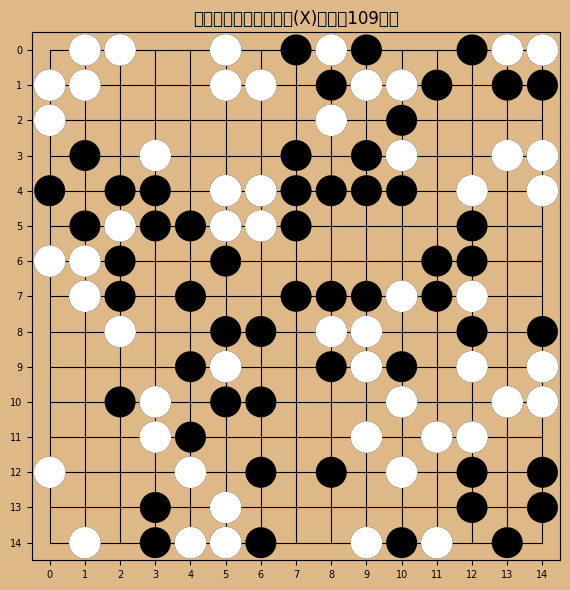

In [8]:
def render_board(board: np.ndarray, title: str = "五子棋棋盘"):
    """用 matplotlib 渲染棋盘"""
    n = board.shape[0]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_facecolor('#DEB887')
    fig.patch.set_facecolor('#DEB887')

    # 画网格线
    for i in range(n):
        ax.plot([0, n-1], [i, i], 'k-', linewidth=0.8)
        ax.plot([i, i], [0, n-1], 'k-', linewidth=0.8)

    # 画棋子
    for r in range(n):
        for c in range(n):
            if board[r, c] == 1:
                circle = plt.Circle((c, n-1-r), 0.42, color='black', zorder=3)
                ax.add_patch(circle)
            elif board[r, c] == -1:
                circle = plt.Circle((c, n-1-r), 0.42, color='white', zorder=3,
                                    linewidth=1.5, fill=True)
                edge = plt.Circle((c, n-1-r), 0.42, color='black', zorder=2,
                                  fill=False, linewidth=1.5)
                ax.add_patch(circle)
                ax.add_patch(edge)

    ax.set_xlim(-0.5, n-0.5)
    ax.set_ylim(-0.5, n-0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([str(i) for i in range(n)], fontsize=7)
    ax.set_yticklabels([str(n-1-i) for i in range(n)], fontsize=7)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# 渲染刚才那局的最终棋盘
final_board = result['transitions'][-1]['next_state']
winner_str = {1: '黑(X)胜', -1: '白(O)胜', 0: '平局'}.get(result['winner'], '')
render_board(final_board, title=f"随机对战最终局面（{winner_str}，共{result['total_steps']}步）")

## Cell 7：统计 100 局随机对战

用大量 episode 统计黑白胜率，验证环境没有系统性偏差。

共 200 局随机对战
  黑(X)胜: 109  (54.5%)
  白(O)胜:  91  (45.5%)
  平局:      0  (0.0%)
  平均步数: 105.7  最短: 41  最长: 178


/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/2740259433.py:42: UserWarning: Glyph 40657 (\N{CJK UNIFIED IDEOGRAPH-9ED1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/2740259433.py:42: UserWarning: Glyph 32988 (\N{CJK UNIFIED IDEOGRAPH-80DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/2740259433.py:42: UserWarning: Glyph 30333 (\N{CJK UNIFIED IDEOGRAPH-767D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/2740259433.py:42: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqvzmls4yg4j_nc8kqtsvs40000gn/T/ipykernel_78171/2740259433.py:42: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3z/hjqv

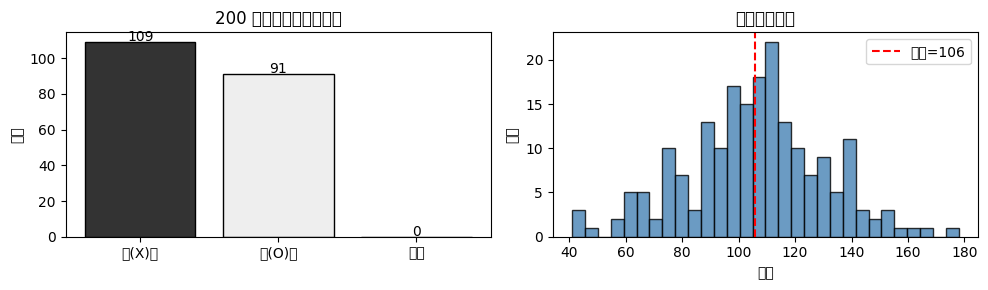

In [9]:
N = 200
env = GomokuEnv()
winners = []
steps_list = []

for _ in range(N):
    result = run_episode(env)
    winners.append(result['winner'])
    steps_list.append(result['total_steps'])

winners = np.array(winners)
black_wins = (winners == 1).sum()
white_wins = (winners == -1).sum()
draws = (winners == 0).sum()

print(f"共 {N} 局随机对战")
print(f"  黑(X)胜: {black_wins:3d}  ({black_wins/N*100:.1f}%)")
print(f"  白(O)胜: {white_wins:3d}  ({white_wins/N*100:.1f}%)")
print(f"  平局:    {draws:3d}  ({draws/N*100:.1f}%)")
print(f"  平均步数: {np.mean(steps_list):.1f}  最短: {np.min(steps_list)}  最长: {np.max(steps_list)}")

# 步数分布图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# 胜负分布
bars = ax1.bar(['黑(X)胜', '白(O)胜', '平局'], [black_wins, white_wins, draws],
               color=['#333', '#eee', '#aaa'], edgecolor='black')
ax1.set_title(f'{N} 局随机对战胜负分布')
ax1.set_ylabel('局数')
for bar, val in zip(bars, [black_wins, white_wins, draws]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=10)

# 步数分布
ax2.hist(steps_list, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax2.set_title('每局步数分布')
ax2.set_xlabel('步数')
ax2.set_ylabel('频次')
ax2.axvline(np.mean(steps_list), color='red', linestyle='--', label=f'均值={np.mean(steps_list):.0f}')
ax2.legend()

plt.tight_layout()
plt.show()

## 小结 & 下一步

### 本 notebook 完成了什么

| 目标 | 状态 |
|---|---|
| 实现 `GomokuEnv` 核心接口（reset/step/get_legal_actions） | 完成 |
| 验证四方向五连检测 | 完成 |
| 跑通随机策略完整 episode，收集 transitions | 完成 |
| 可视化棋盘终局 | 完成 |
| 统计多局胜率分布 | 完成 |

### RL 概念已建立直觉

- **State** = `board`（15×15 int8 array）
- **Action** = `0~224` 整数（`row*15+col`）
- **Reward** = +1（赢）/ 0（未结束/平）/ -1（非法动作触发输）
- **Episode** = 一局棋，由 `done=True` 结束
- **Transition** = `(s, a, r, s', done)` 是所有 RL 算法的基本数据单元
- **Policy** = `action = f(state)`，当前是 `random_policy`

### 下一步：`02_q_learning.ipynb`

用 **Q-Learning** 训练一个真正会学习的 Agent：
- Q 表 / Q 网络：`Q(state, action) → 期望累计奖励`
- Bellman 方程更新
- ε-greedy 探索策略（Explore vs Exploit）